In [1]:
# Dataset downloading
import kagglehub

# Download latest version
path = kagglehub.dataset_download("patrickb1912/ipl-complete-dataset-20082020")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ipl-complete-dataset-20082020' dataset.
Path to dataset files: /kaggle/input/ipl-complete-dataset-20082020


In [3]:
!mkdir data/
!mv /kaggle/input/ipl-complete-dataset-20082020/* /content/data/

mkdir: cannot create directory ‘data/’: File exists
mv: cannot remove '/kaggle/input/ipl-complete-dataset-20082020/deliveries.csv': Read-only file system
mv: cannot remove '/kaggle/input/ipl-complete-dataset-20082020/matches.csv': Read-only file system


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data = pd.read_csv("/content/data/matches.csv")
data.sample(5)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
292,548353,2012,Kolkata,2012-05-05,League,SP Narine,Eden Gardens,Kolkata Knight Riders,Pune Warriors,Kolkata Knight Riders,bat,Kolkata Knight Riders,runs,7.0,151.0,20.0,N,NaN,BF Bowden,SK Tarapore
235,501259,2011,Mumbai,2011-05-16,League,A Mishra,Dr DY Patil Sports Academy,Pune Warriors,Deccan Chargers,Deccan Chargers,field,Deccan Chargers,wickets,6.0,137.0,20.0,N,NaN,S Ravi,SK Tarapore
557,980981,2016,Bangalore,2016-05-11,League,KH Pandya,M Chinnaswamy Stadium,Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,field,Mumbai Indians,wickets,6.0,152.0,20.0,N,NaN,AY Dandekar,C Shamshuddin
709,1175369,2019,Jaipur,2019-04-02,League,S Gopal,Sawai Mansingh Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,7.0,159.0,20.0,N,NaN,AY Dandekar,M Erasmus
189,501212,2011,Hyderabad,2011-04-16,League,PC Valthaty,"Rajiv Gandhi International Stadium, Uppal",Deccan Chargers,Kings XI Punjab,Kings XI Punjab,field,Kings XI Punjab,wickets,8.0,166.0,20.0,N,NaN,RE Koertzen,S Ravi


## **Basic EDA**

In [6]:
data.columns

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [8]:
# Dropping columns like id and names of umpire and player of match
data.drop(["id","umpire1", "umpire2","player_of_match"], axis=1,inplace=True)

In [9]:
# converting date from object to datetime object
data["date"] = pd.to_datetime(data["date"])

In [10]:
data.describe()

,date,result_margin,target_runs,target_overs
count,1095,1076.000000,1092.000000,1092.000000
mean,2016-06-25 11:39:36.986301184,17.259294,165.684066,19.759341
min,2008-04-18 00:00:00,1.000000,43.000000,5.000000
25%,2012-04-21 00:00:00,6.000000,146.000000,20.000000
50%,2016-05-03 00:00:00,8.000000,166.000000,20.000000
75%,2021-04-13 12:00:00,20.000000,187.000000,20.000000
max,2024-05-26 00:00:00,146.000000,288.000000,20.000000
std,NaN,21.787444,33.427048,1.581108


In [11]:
data.shape

(1095, 16)

# **Exploring nulls**

In [12]:
# total number of nulls
data.isna().sum().sort_values(ascending=False)

,0
method,1074
city,51
result_margin,19
winner,5
target_runs,3
target_overs,3
date,0
season,0
toss_winner,0
team2,0


In [13]:
# Calculate % of nulls for each column
((data.isna().sum()/data.shape[0]).sort_values(ascending=False))*100

,0
method,98.082192
city,4.657534
result_margin,1.735160
winner,0.456621
target_runs,0.273973
target_overs,0.273973
date,0.000000
season,0.000000
toss_winner,0.000000
team2,0.000000


In [14]:
"""
Guide:

0-5% missing -> mean / median / mode
5-15% missing -> mean (normal data), median (skewed data), mode (categorical col)
15-30% missing -> KNNImputer, MICE
30-50% missing -> Advanced techniques only if column important
50-70% missing -> Drop if not highly relevant
>70% -> Drop
"""

'\nGuide:\n\n0-5% missing -> mean / median / mode\n5-15% missing -> mean (normal data), median (skewed data), mode (categorical col)\n15-30% missing -> KNNImputer, MICE\n30-50% missing -> Advanced techniques only if column important\n50-70% missing -> Drop if not highly relevant\n>70% -> Drop\n'

In [15]:
data.drop("method", axis=1, inplace=True)   # Drop as >90% missing

# **Studying Data**

In [16]:
data.columns

Index(['season', 'city', 'date', 'match_type', 'venue', 'team1', 'team2',
       'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin',
       'target_runs', 'target_overs', 'super_over'],
      dtype='object')

In [17]:
cat_col = [col for col in data.columns if data[col].dtype=="object"]
num_col = [col for col in data.columns if col not in cat_col and col != "date"]

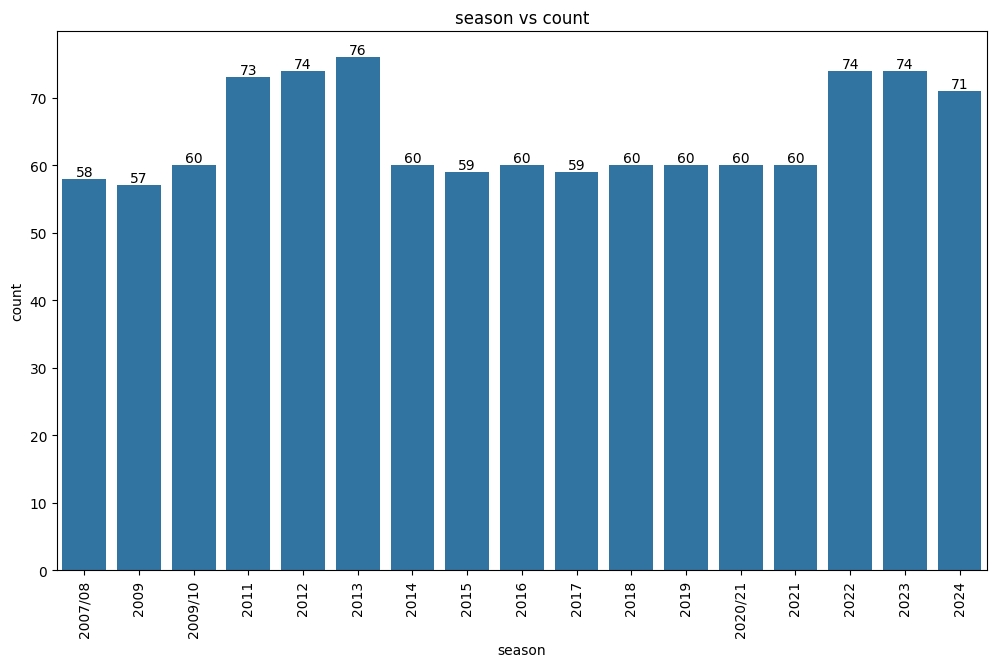

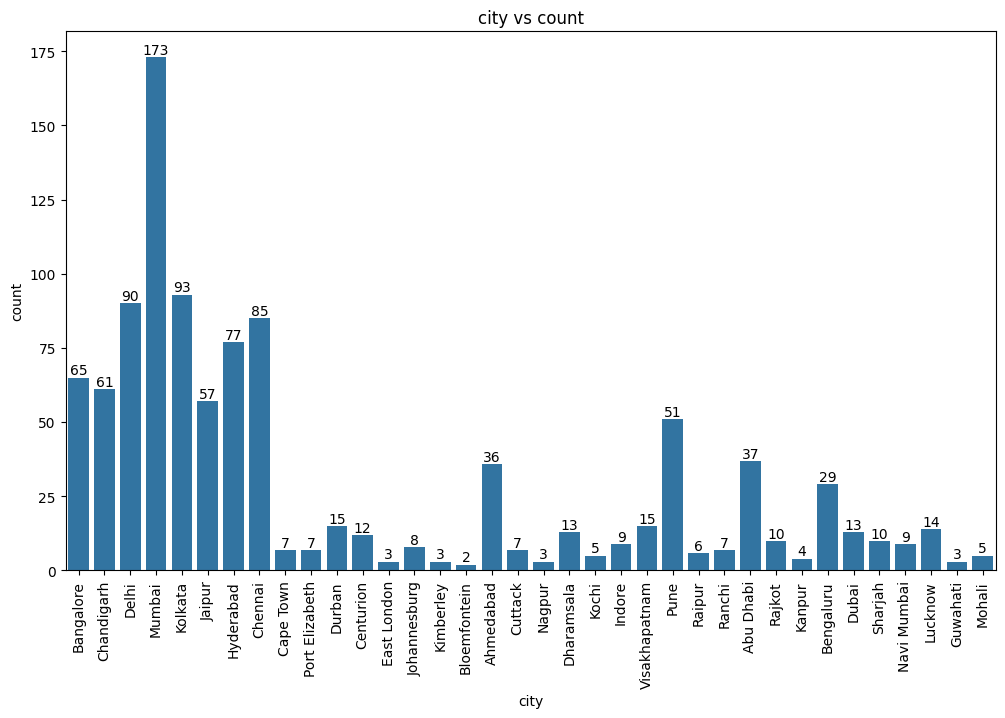

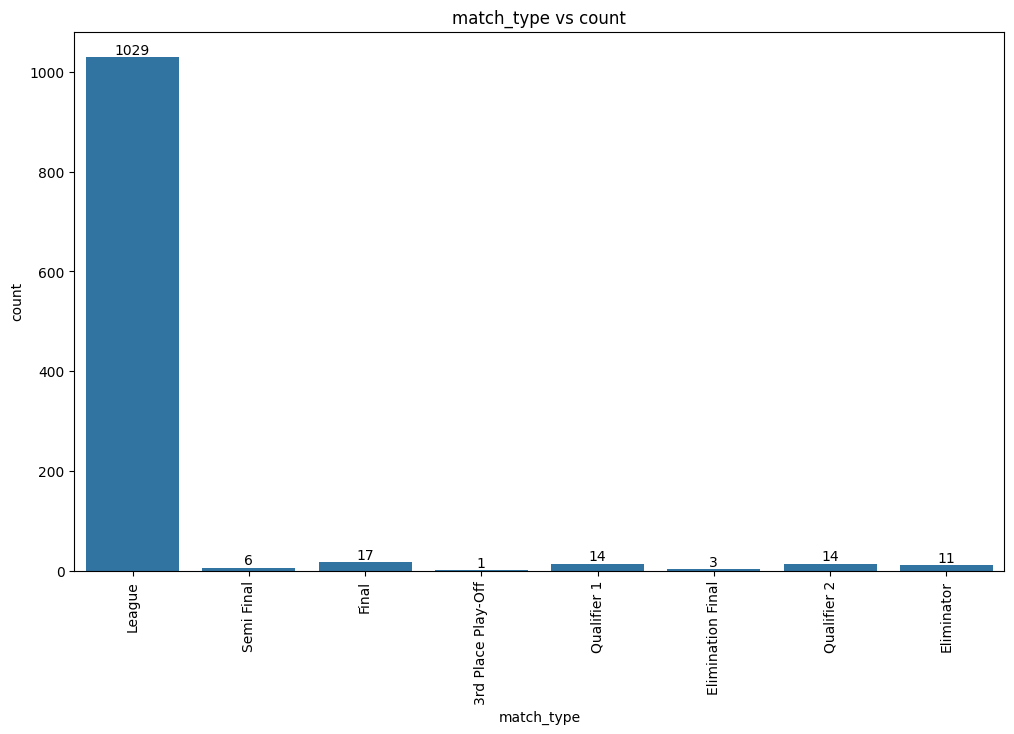

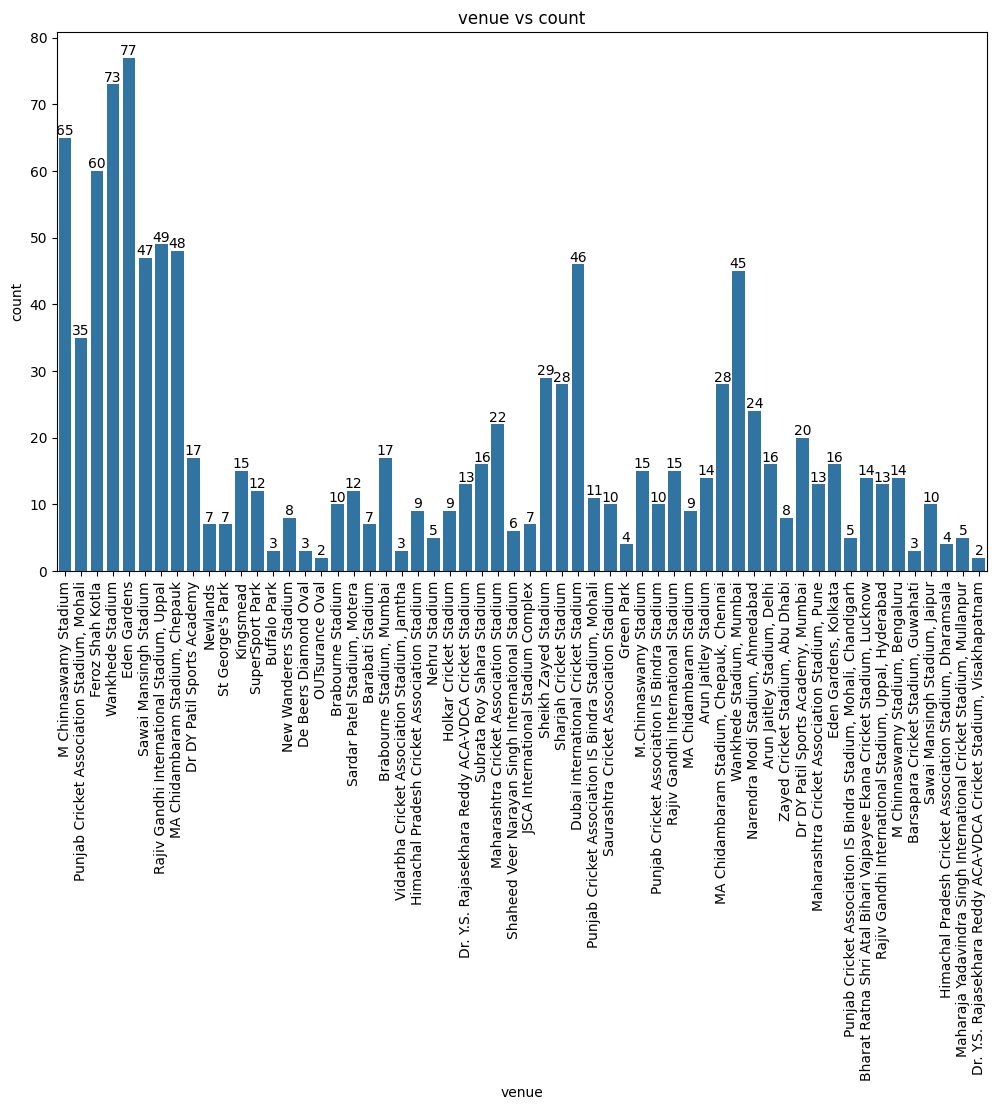

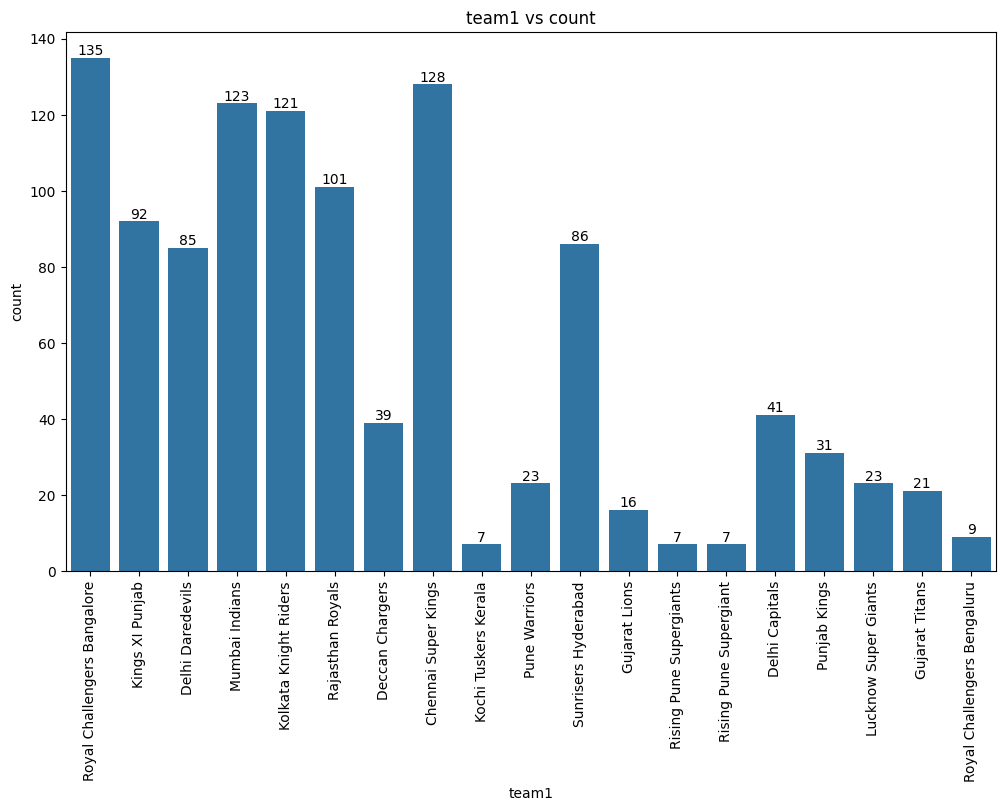

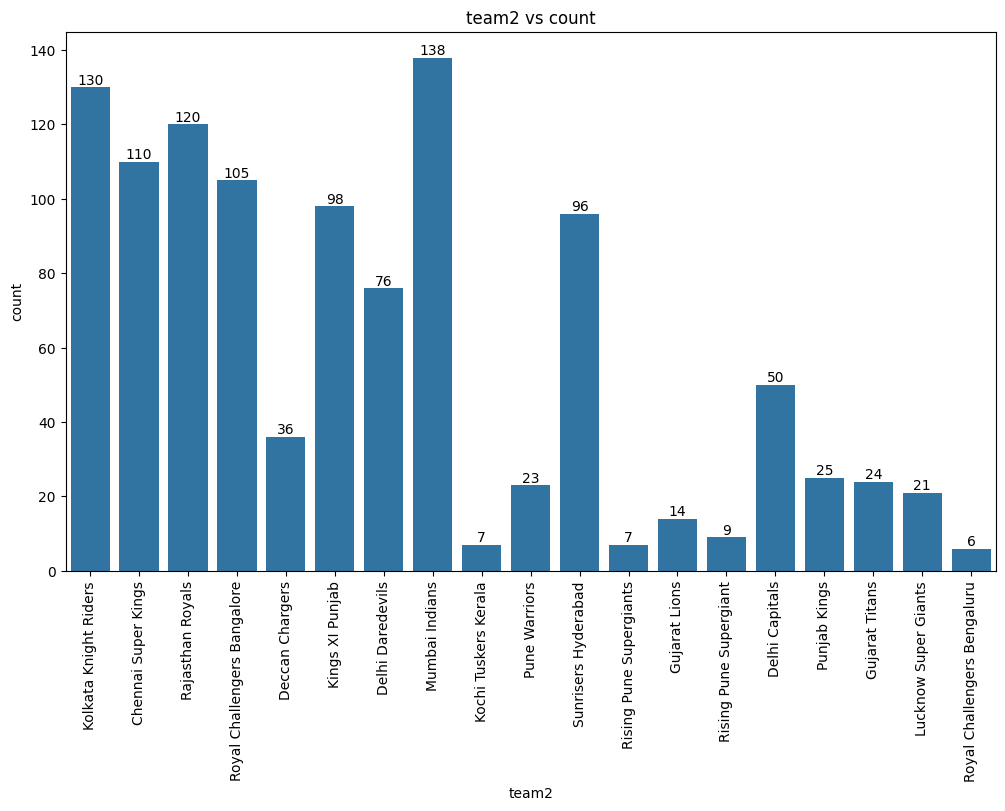

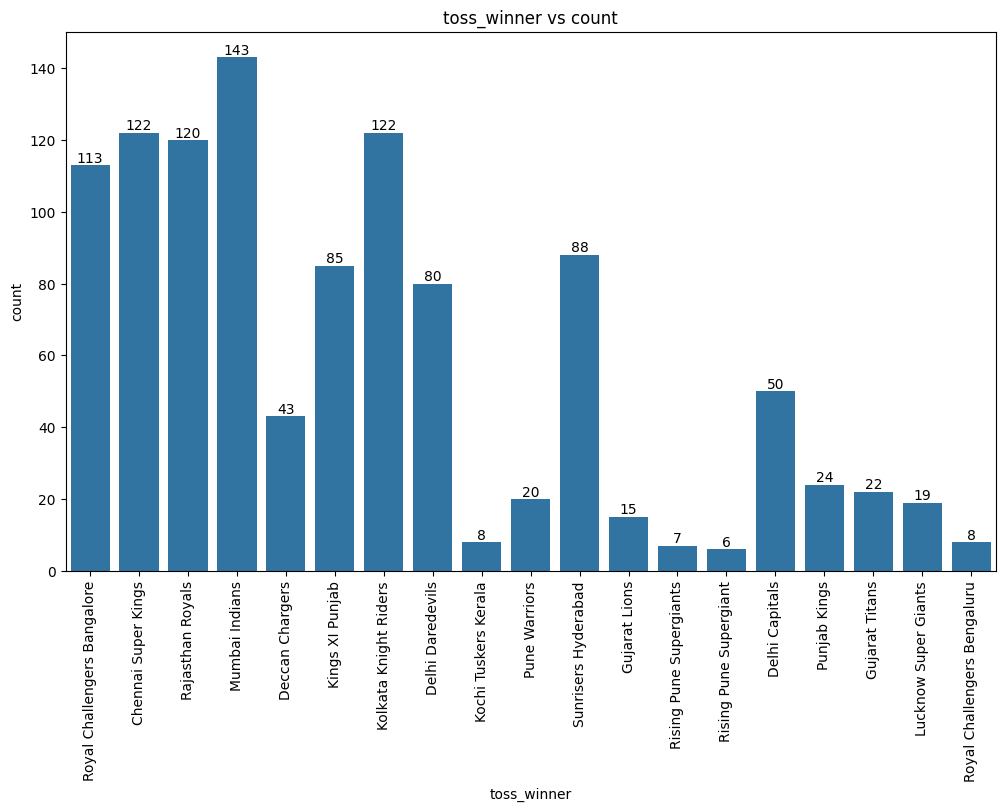

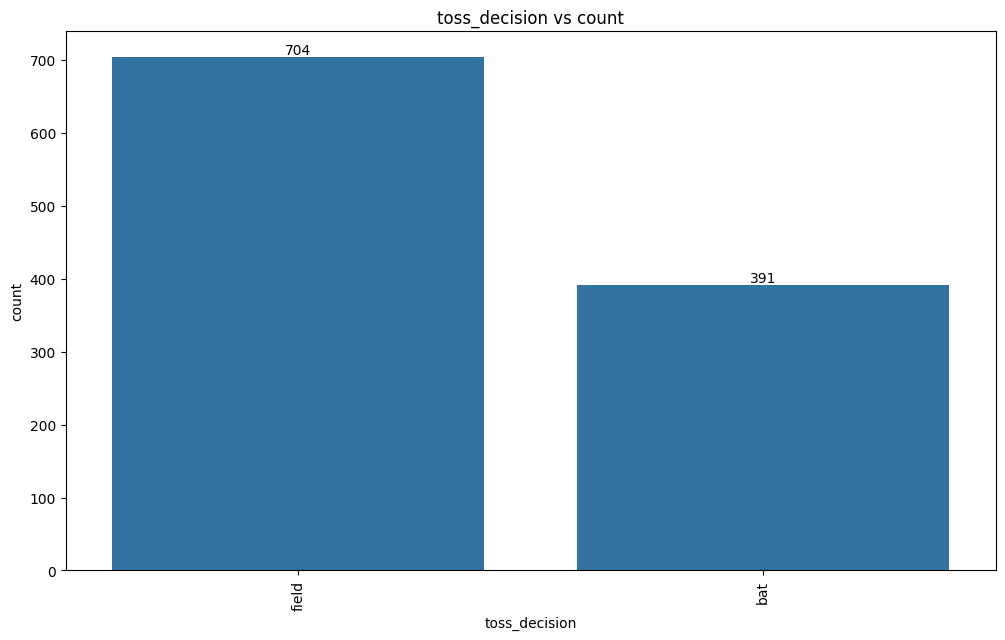

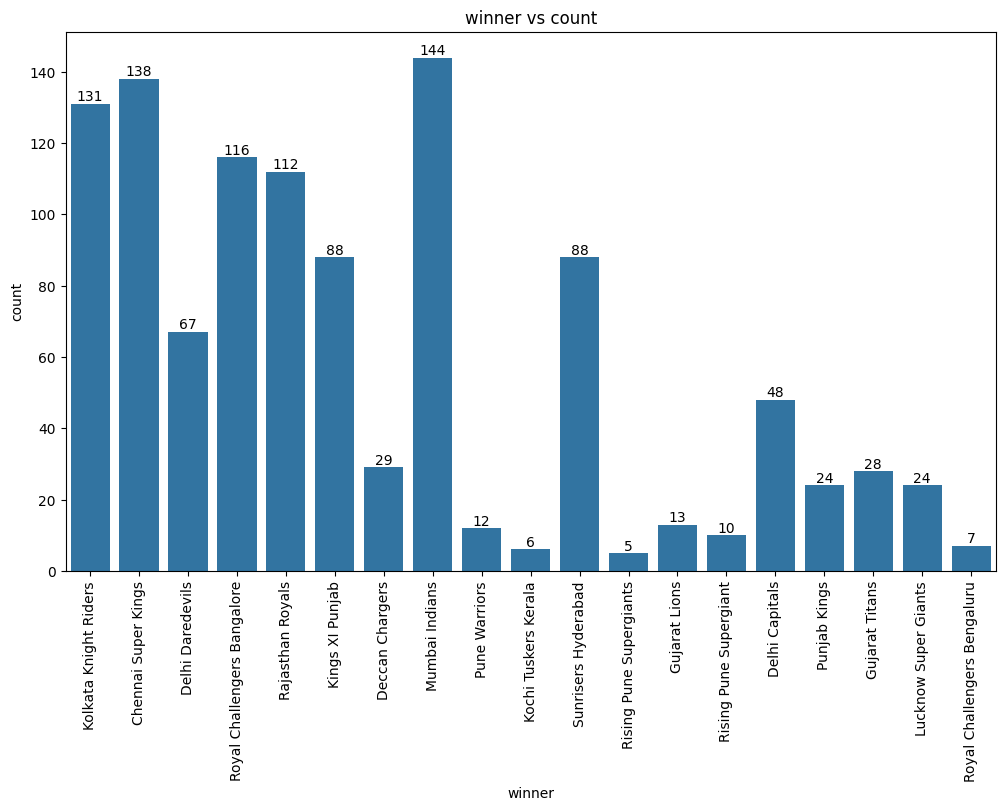

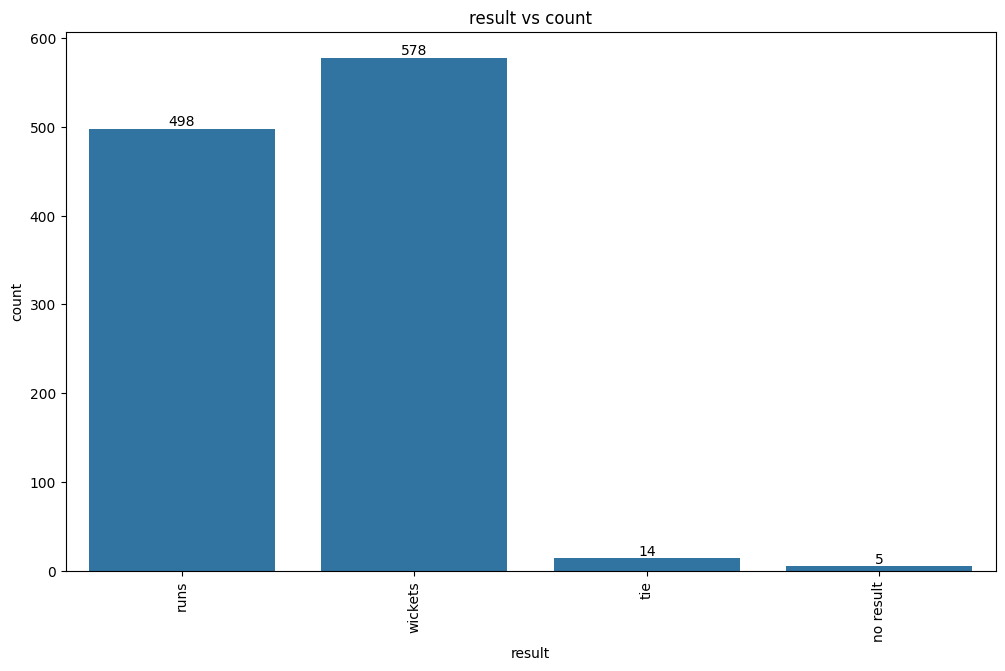

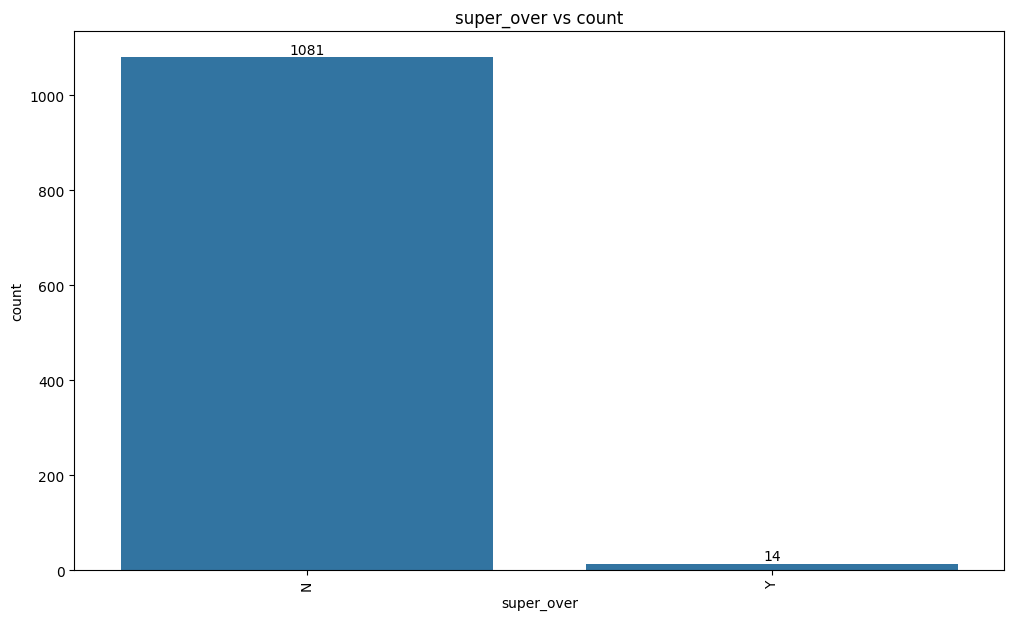

In [18]:
for cat in cat_col:
  plt.figure(figsize=(12,7))
  print("\n")

  plt.title(f"{cat} vs count")
  ax = sns.countplot(data=data,x=cat)
  ax.bar_label(ax.containers[0])

  plt.xticks(rotation=90)
  plt.show()

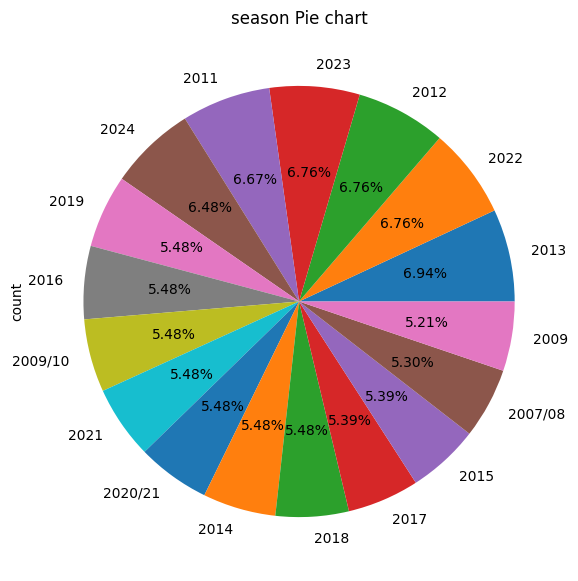

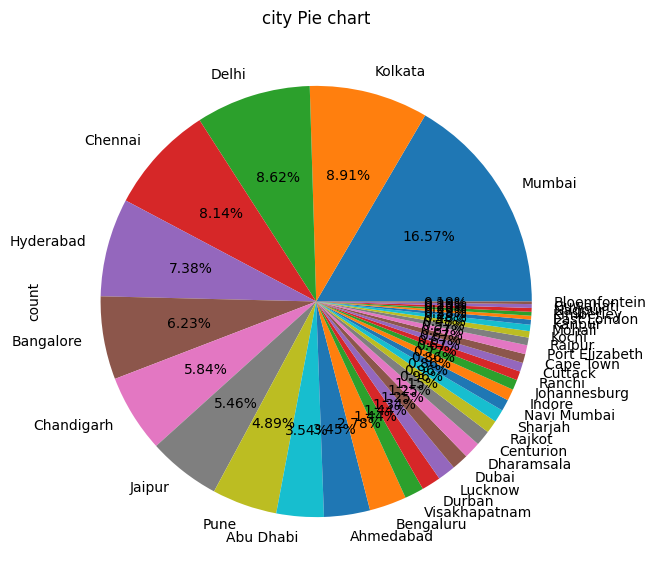

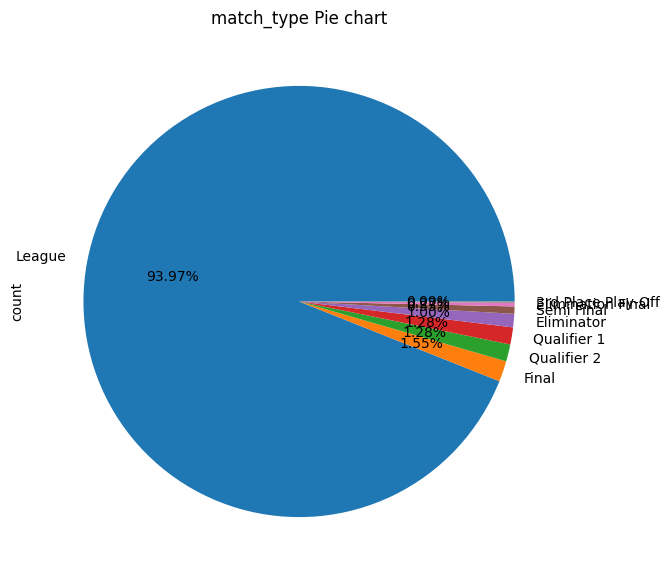

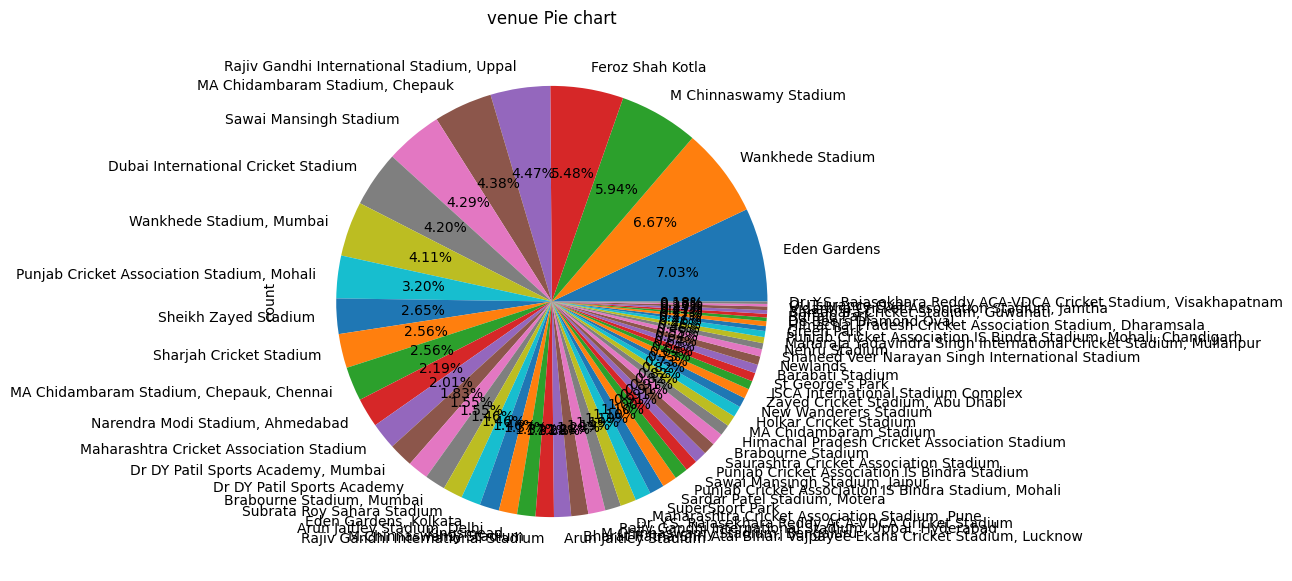

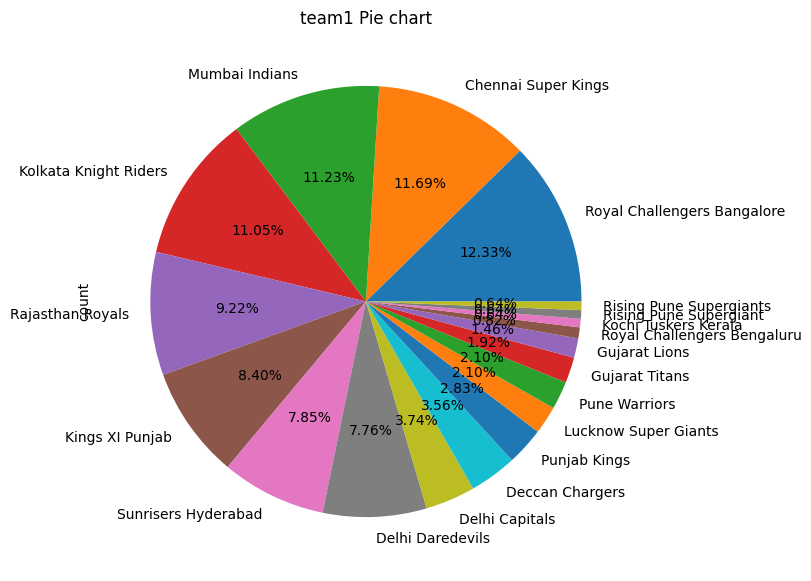

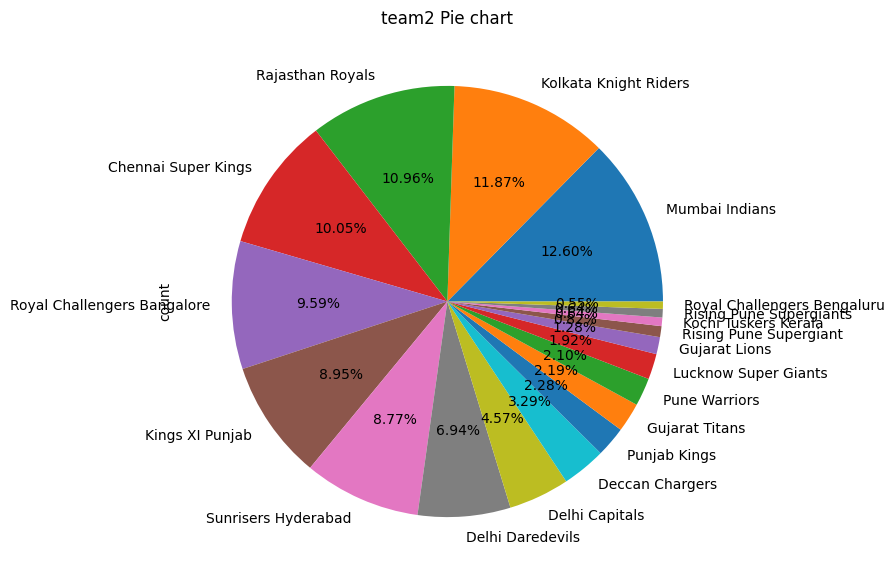

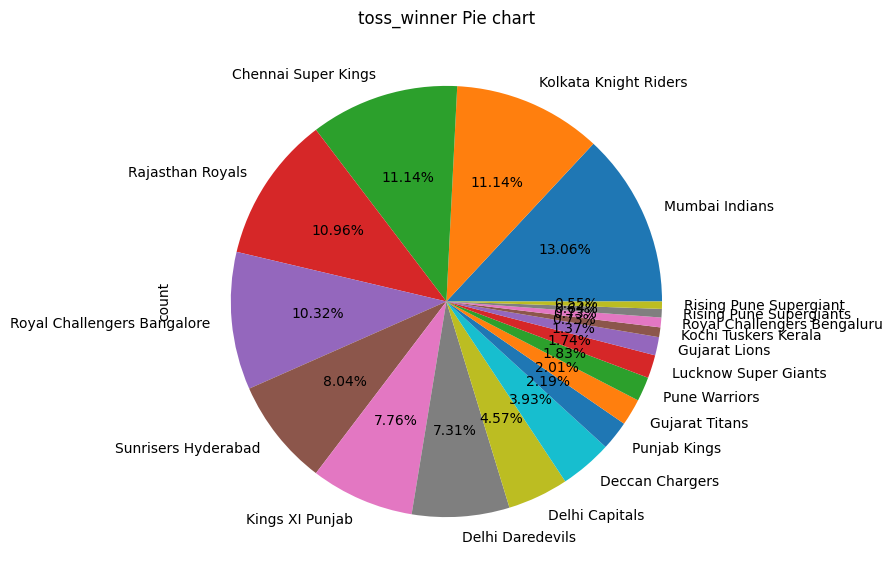

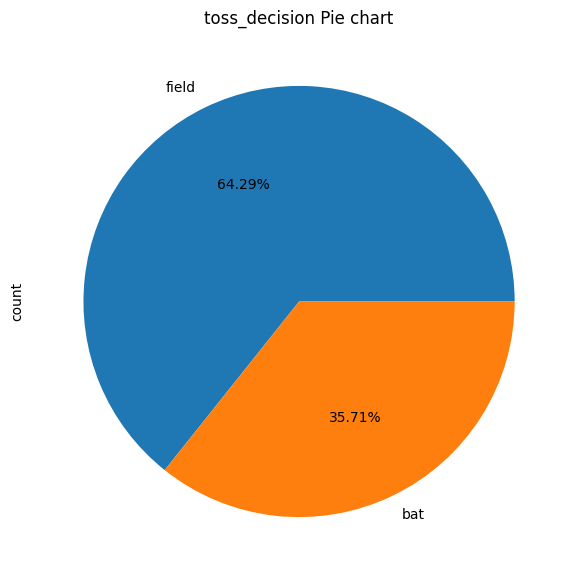

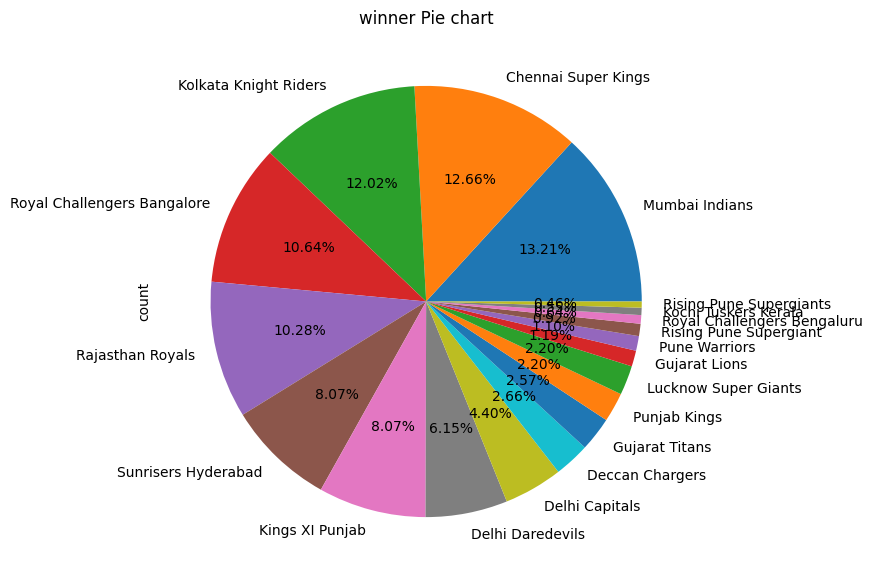

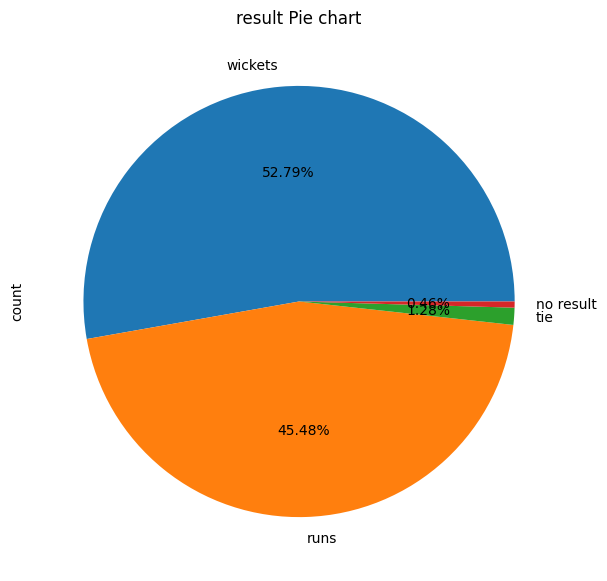

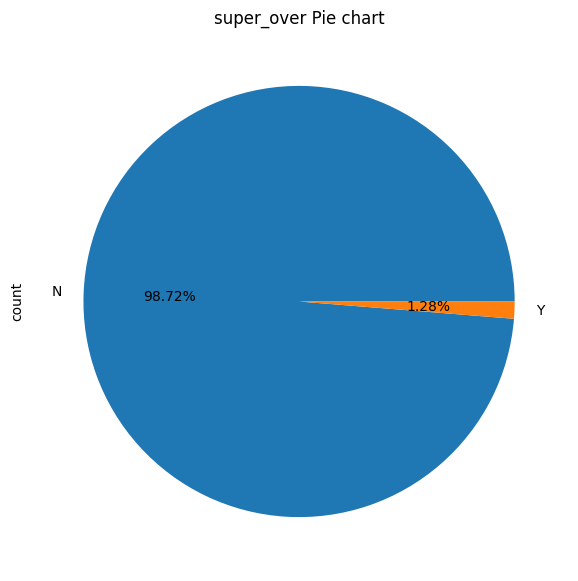

In [26]:
for cat in cat_col:
  plt.figure(figsize=(12,7))
  print("\n")

  plt.title(f"{cat} Pie chart")
  data[cat].value_counts().plot(kind="pie",autopct="%0.2f%%")

  plt.show()

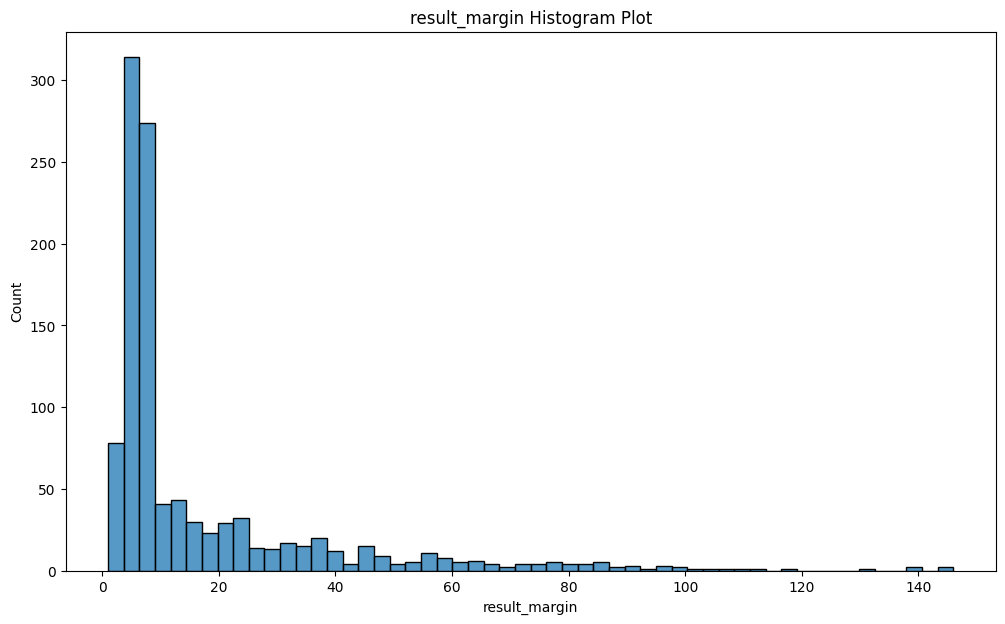

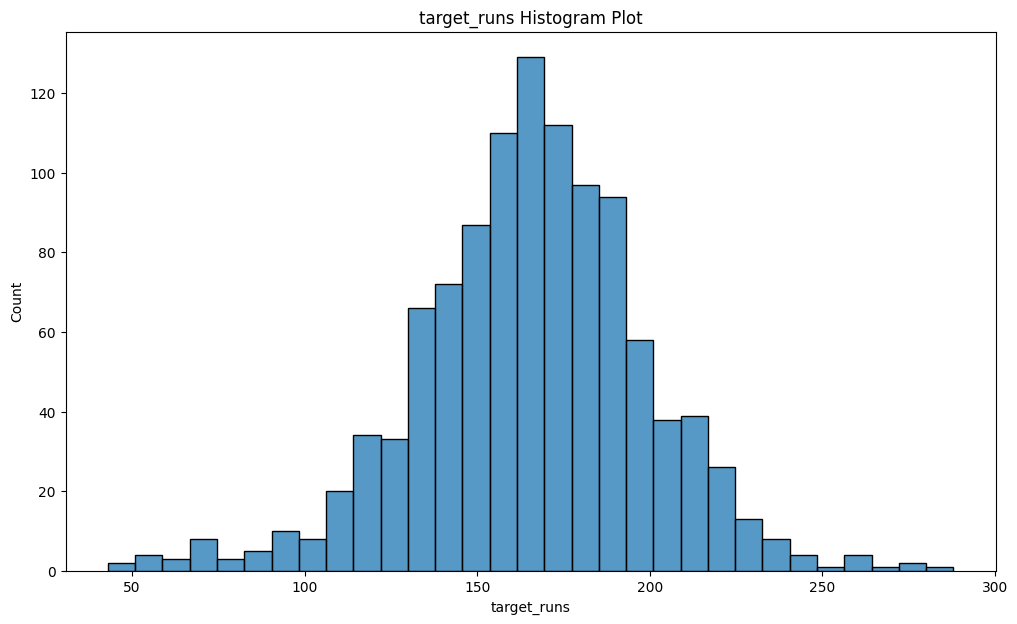

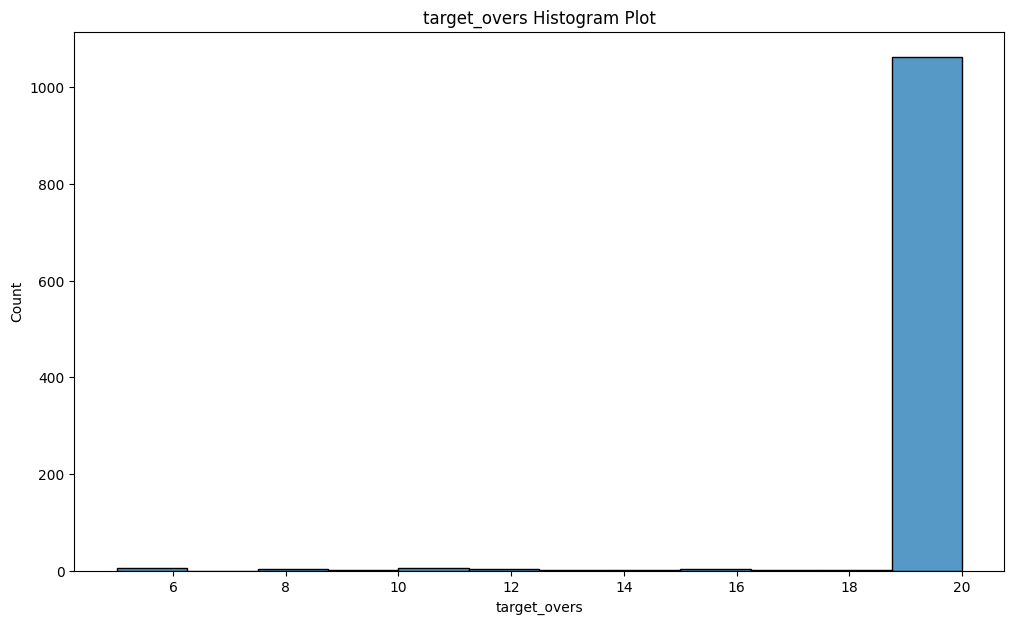

In [176]:
for num in num_col:
  print("\n")
  plt.figure(figsize=(12,7))
  plt.title(f"{num} Histogram Plot")
  sns.histplot(data=data,x=num)
  plt.show()

In [177]:
# Handling nulls:

data["city"] = data["city"].fillna(data["city"].mode()[0])  # Filling missing cat column with mode as < 5% data missing
data["result_margin"] = data["result_margin"].fillna(data["result_margin"].median()) # Filling missing num column with median as < 5% data missing and skewed data
data = data.dropna(subset=["winner","player_of_match", "target_overs", "target_runs"])  # Dropping null rows as < 0.5% data missing

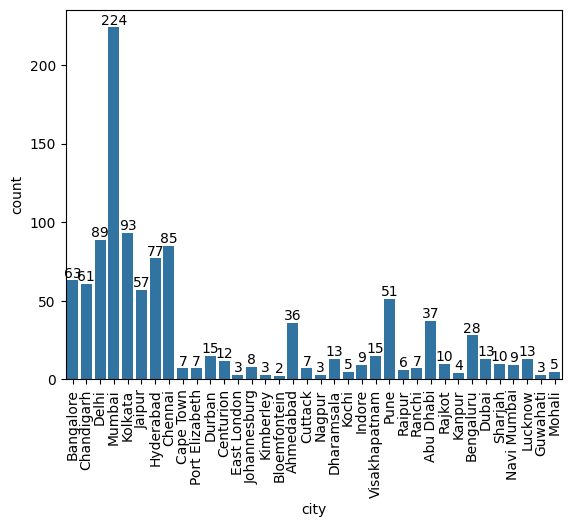

In [178]:
ax = sns.countplot(x="city", data=data)

ax.bar_label(ax.containers[0])
plt.xticks(rotation=90)
plt.show()

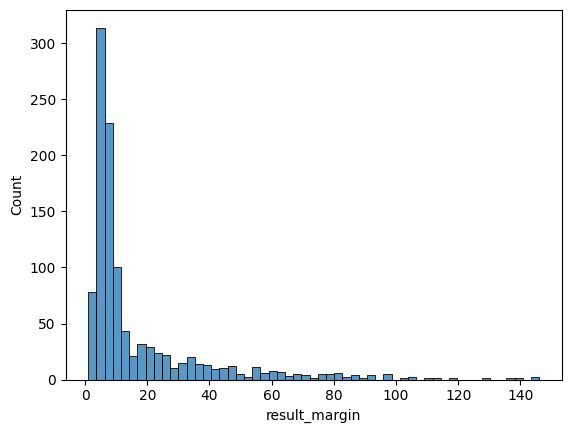

In [179]:
sns.histplot(x="result_margin", data=data)
plt.show()

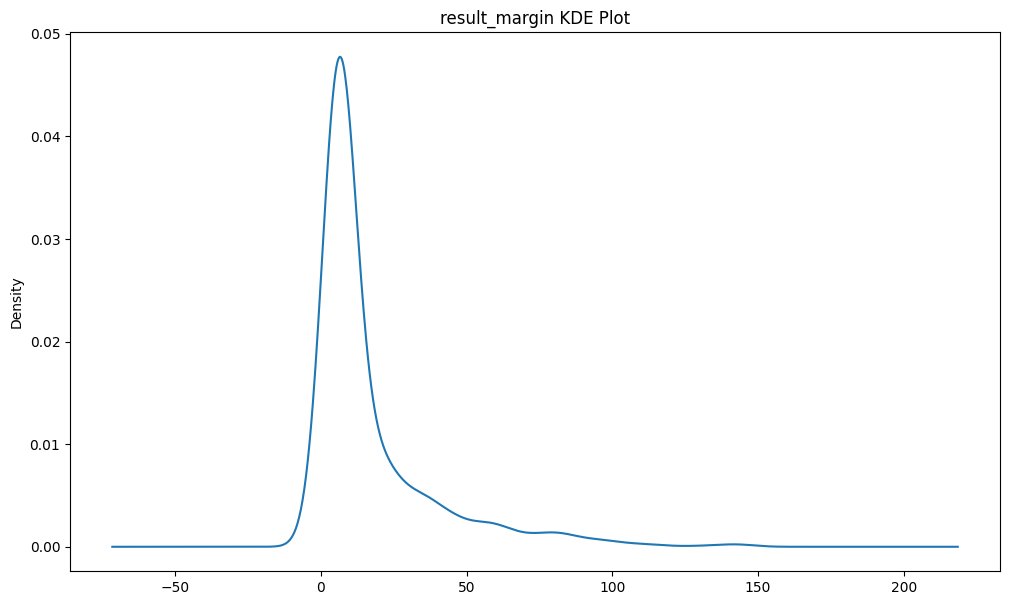

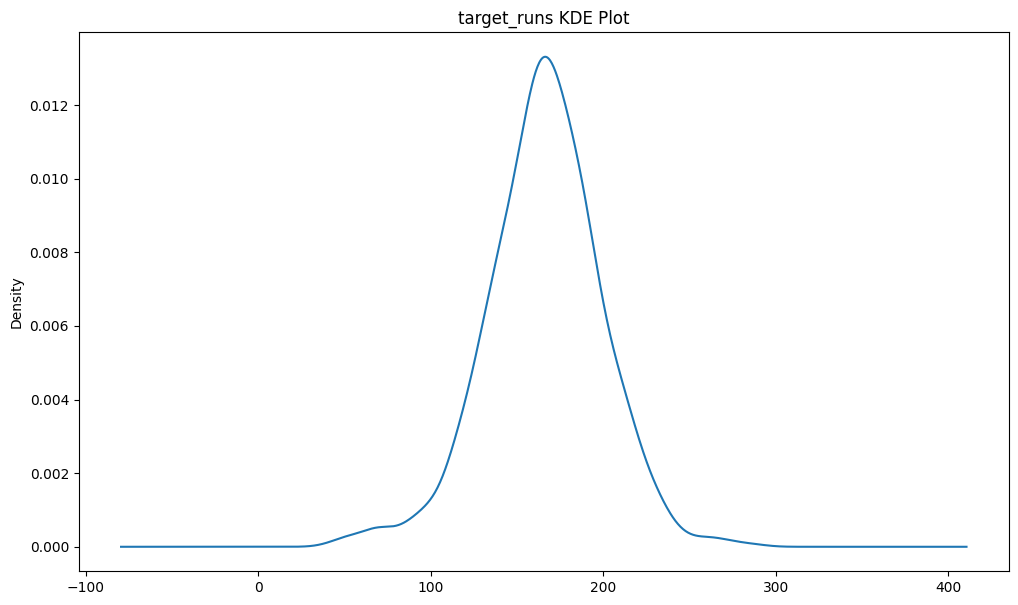

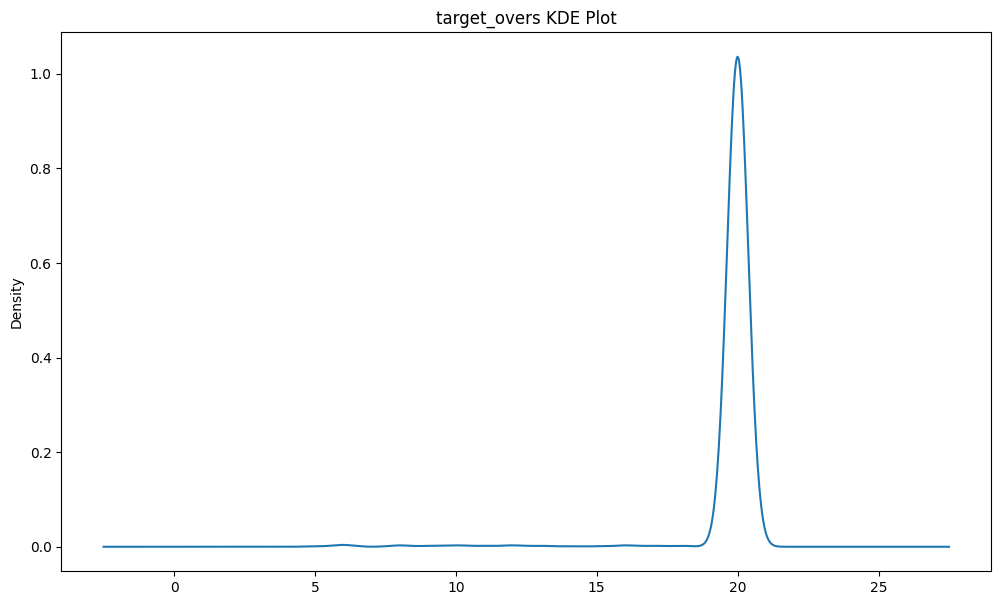

In [180]:
for num in num_col:
  print("\n")
  plt.figure(figsize=(12,7))
  plt.title(f"{num} KDE Plot")
  data[num].plot(kind="kde")
  plt.show()

# **Queries**

In [181]:
data.sample(3)

,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over
80,2009,Port Elizabeth,2009-05-02,League,YK Pathan,St George's Park,Deccan Chargers,Rajasthan Royals,Deccan Chargers,bat,Rajasthan Royals,wickets,3.0,142.0,20.0,N
323,2013,Bangalore,2013-04-04,League,CH Gayle,M Chinnaswamy Stadium,Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,field,Royal Challengers Bangalore,runs,2.0,157.0,20.0,N
794,2020/21,Abu Dhabi,2020-10-21,League,Mohammed Siraj,Sheikh Zayed Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders,bat,Royal Challengers Bangalore,wickets,8.0,85.0,20.0,N


In [182]:
# Get number of times each team has one
data[data["match_type"] == "Final"]["winner"].value_counts()

,count
winner,
Chennai Super Kings,5
Mumbai Indians,5
Kolkata Knight Riders,3
Deccan Chargers,1
Rajasthan Royals,1
Sunrisers Hyderabad,1
Gujarat Titans,1


In [183]:
# Get number of matches played by RCB
data[(data["team1"] == "Royal Challengers Bangalore") | (data["team2"] == "Royal Challengers Bangalore")].shape[0]

237

# Bivariate **analysis**

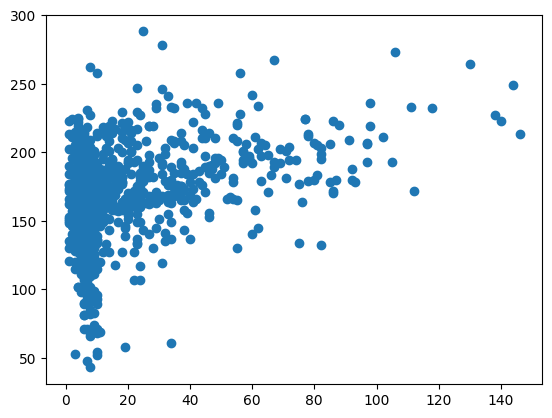

In [184]:
plt.scatter(data["result_margin"], data["target_runs"])
plt.show()

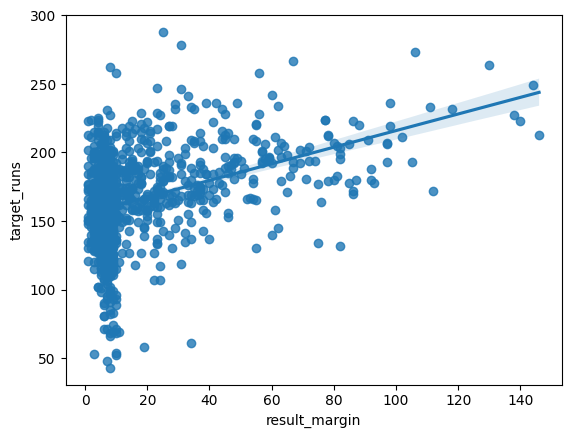

In [185]:
sns.regplot(data=data,x="result_margin", y="target_runs")
plt.show()

In [186]:
cat_col

['season',
 'city',
 'match_type',
 'player_of_match',
 'venue',
 'team1',
 'team2',
 'toss_winner',
 'toss_decision',
 'winner',
 'result',
 'super_over',
 'method']

In [187]:
pd.crosstab(data["city"], data["winner"])

winner,Chennai Super Kings,Deccan Chargers,Delhi Capitals,Delhi Daredevils,Gujarat Lions,Gujarat Titans,Kings XI Punjab,Kochi Tuskers Kerala,Kolkata Knight Riders,Lucknow Super Giants,Mumbai Indians,Pune Warriors,Punjab Kings,Rajasthan Royals,Rising Pune Supergiant,Rising Pune Supergiants,Royal Challengers Bangalore,Royal Challengers Bengaluru,Sunrisers Hyderabad
city,,,,,,,,,,,,,,,,,,,
Abu Dhabi,4,0,3,0,0,0,2,0,8,0,8,0,0,7,0,0,2,0,3
Ahmedabad,1,0,4,1,0,9,1,0,3,0,1,0,2,10,0,0,2,1,1
Bangalore,4,1,0,3,1,0,5,0,6,0,8,0,0,3,1,0,29,0,2
Bengaluru,2,0,1,0,0,1,0,0,4,2,1,0,0,1,0,0,11,4,1
Bloemfontein,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
Cape Town,0,2,0,1,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0
Centurion,2,2,0,2,0,0,0,0,1,0,1,0,0,2,0,0,2,0,0
Chandigarh,3,0,0,1,2,1,30,0,4,1,5,1,1,3,0,0,5,0,4
Chennai,50,2,2,2,0,0,2,0,5,1,8,1,3,2,0,0,5,0,2


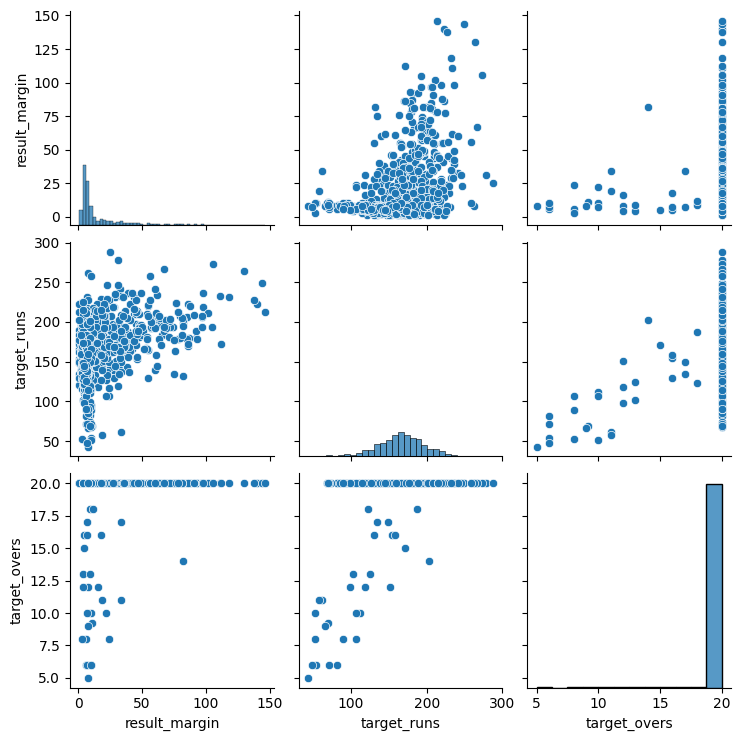

In [188]:
sns.pairplot(data)
plt.show()

In [189]:
data.skew(numeric_only=True)

,0
result_margin,2.590573
target_runs,-0.226575
target_overs,-7.281455


# **Correlation**

In [190]:
data[['result_margin', 'target_runs', 'target_overs']].corr()

,result_margin,target_runs,target_overs
result_margin,1.000000,0.394252,0.030107
target_runs,0.394252,1.000000,0.341386
target_overs,0.030107,0.341386,1.000000


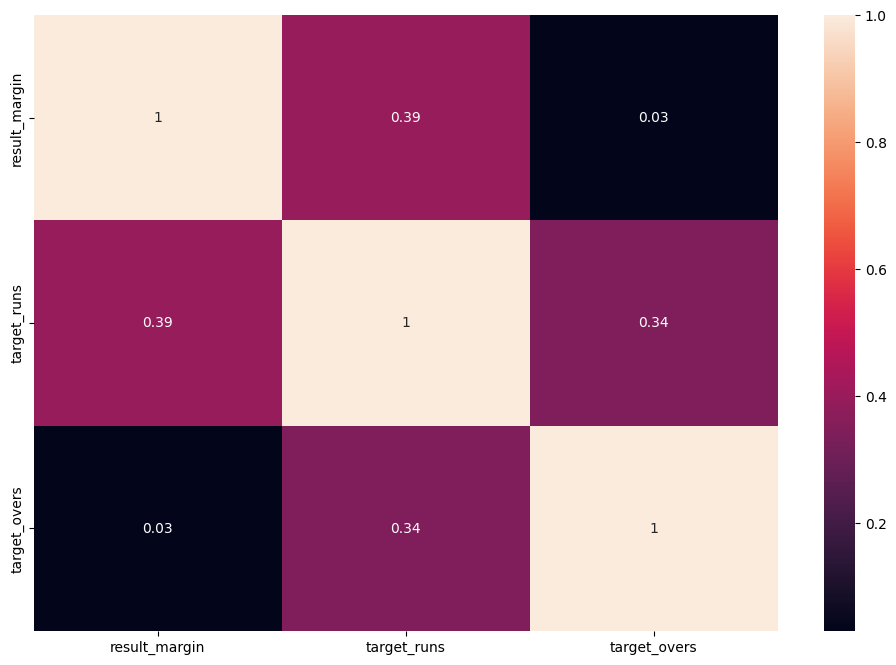

In [191]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(numeric_only=True),
            annot=True)
plt.show()

# **Preprocessing**

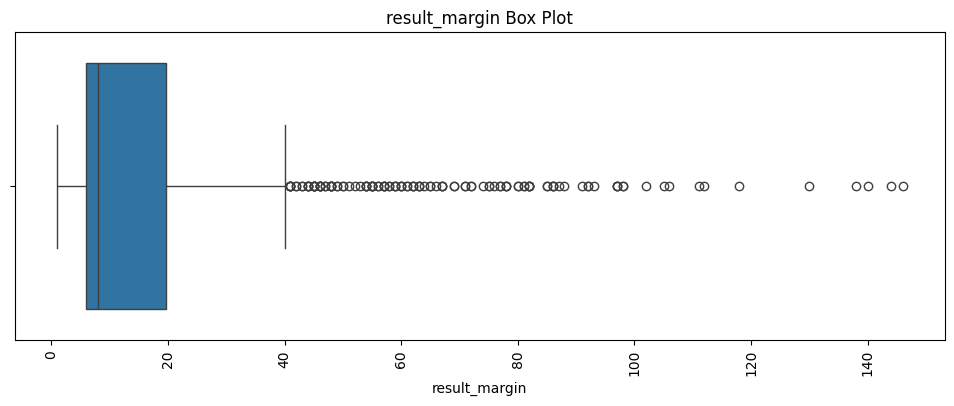

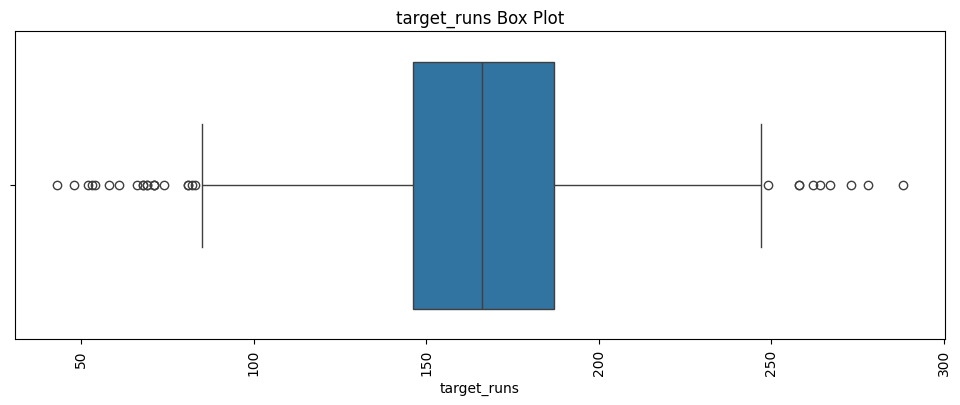

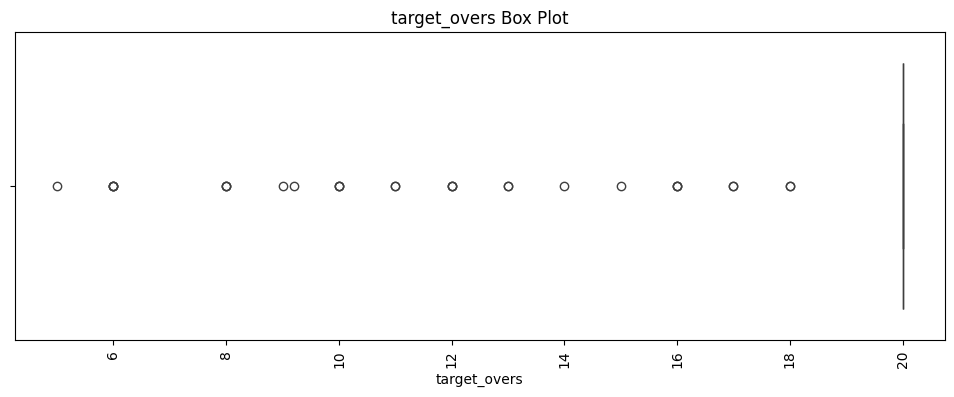

In [192]:
# Outliers detection

for col in num_col:
  print("\n\n")

  plt.figure(figsize=(12,4))
  plt.title(f"{col} Box Plot")
  sns.boxplot(x=col,data=data)
  plt.xticks(rotation=90)
  plt.show()